In [4]:
import warnings
warnings.simplefilter("ignore")

In [12]:
'TIC 261136679 corresponds to Pi Mensae (also known as HD 39091) which is a known host to 3 exoplanets (Pi Mensae b, Pi Mensae c, and Pi Mensae d). Hence, we will be using the TESS light curve data for TIC 261136679 to demonstrate the process of exoplanet transit detection using spectral variability analysis.'

'TIC 261136679 corresponds to Pi Mensae (also known as HD 39091) which is a known host to 3 exoplanets (Pi Mensae b, Pi Mensae c, and Pi Mensae d). Hence, we will be using the TESS light curve data for TIC 261136679 to demonstrate the process of exoplanet transit detection using spectral variability analysis.'

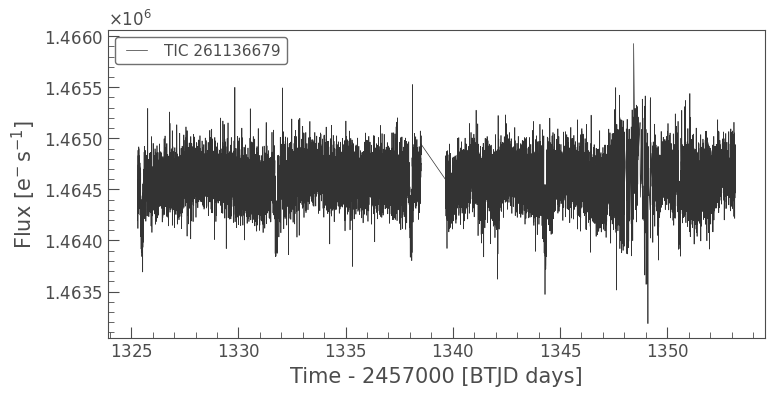

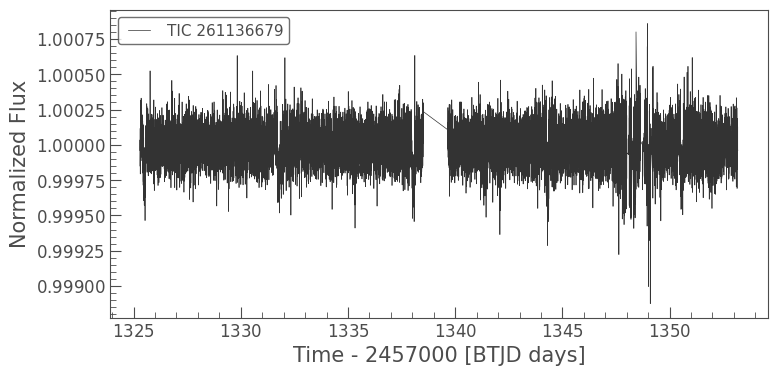

In [61]:
import lightkurve as lk
import matplotlib.pyplot as plt

# Search and download TESS light curve
search_result = lk.search_lightcurve("TIC 261136679", mission="TESS")
lc = search_result.download()

lc = lc.PDCSAP_FLUX
# lc = lc.SAP_FLUX

# Plot raw light curve
lc.plot()
plt.show()

# Flatten (remove long-term trends)
lc_flat = lc.flatten(window_length=1001)

# Plot cleaned light curve
lc_flat.plot()
plt.show()

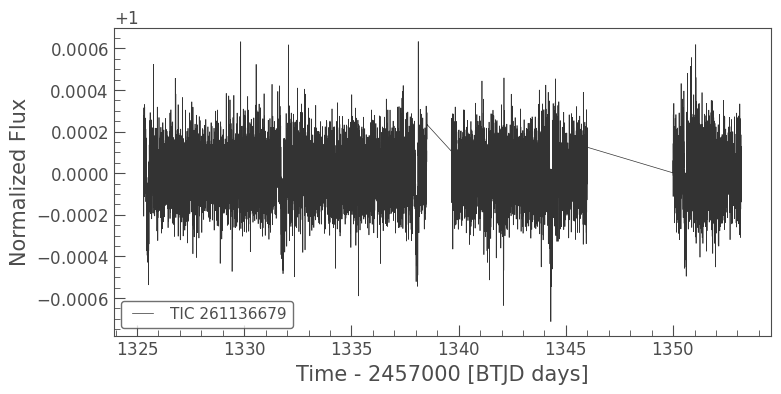

In [ ]:
# Remove unstable observation region
filtered_lc = lc_flat[
    ~((lc_flat.time.value >= 1346) &
      (lc_flat.time.value <= 1350))
]

filtered_lc.plot()
plt.show()

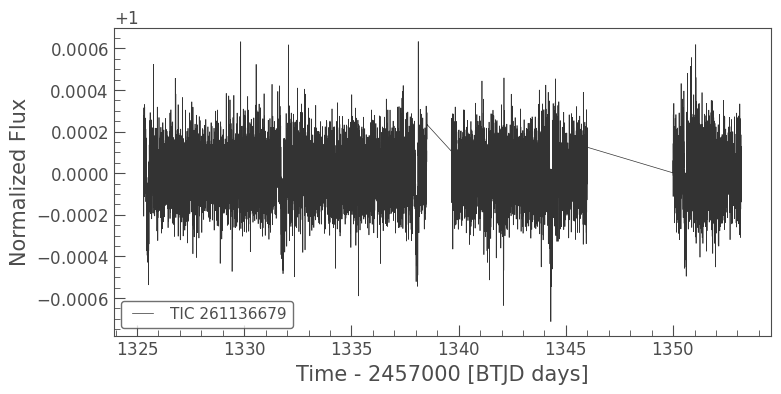

In [78]:
# Remove statistical outliers from the filtered light curve
processed_lc = filtered_lc.remove_outliers(sigma=6)

# Visualize cleaned signal
processed_lc.plot()
plt.show()

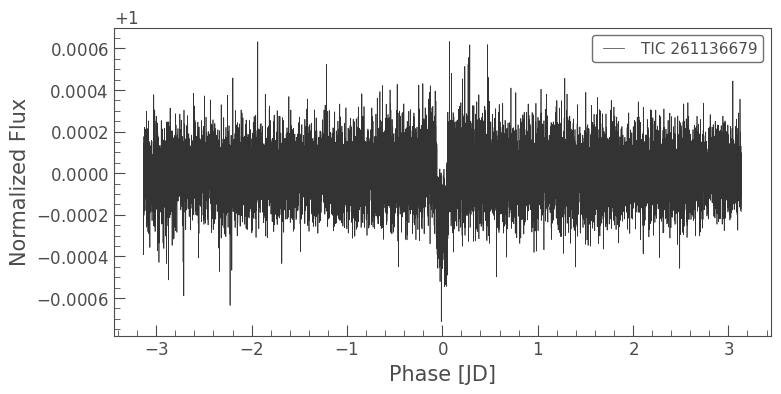

In [105]:
# Fold light curve using known orbital period of Pi Mensae c
phase_folded_lc = processed_lc.fold(
    period=6.27,
    epoch_time=1325.5
)

# Plot folded transit signal
phase_folded_lc.plot()
plt.show()

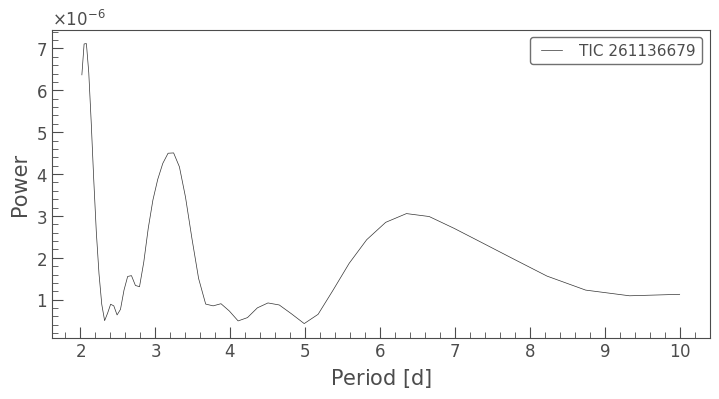

Detected orbital period: 2.0824681395647073 d


In [80]:
# Compute Lomb–Scargle periodogram to search for periodic signals
periodogram = processed_lc.to_periodogram(
    method="lombscargle",
    minimum_period=2,
    maximum_period=10
)

# Visualize detected frequency power spectrum
periodogram.plot()
plt.show()

# Output strongest detected periodic signal
print("Detected orbital period:", periodogram.period_at_max_power)

6.278663461778693 d


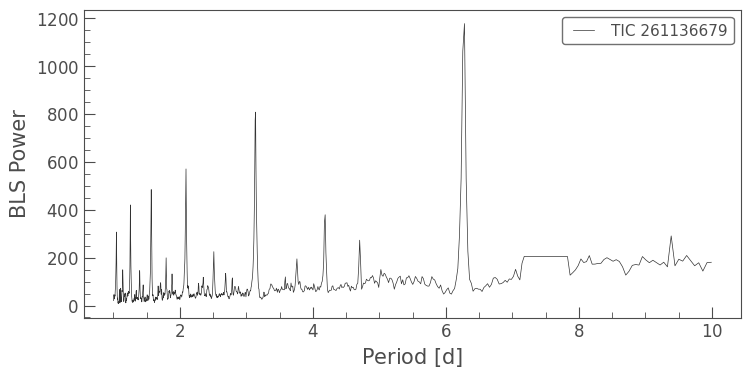

In [111]:
pg = clipped_lc.to_periodogram(
    method="bls",
    minimum_period=1,
    maximum_period=10
)

pg.plot()
print(pg.period_at_max_power)
plt.show()
